# Transaction Analytics EDA

**Banking Analytics Intelligence Platform** — Tanzania Banking Portfolio

This notebook analyzes transaction volume, value, channel adoption, temporal patterns, and regional activity to support digital banking and operations strategy.


In [1]:
# Reusable transaction analytics utilities
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'transaction_analysis'
CHART_DIR = REPORT_DIR / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})

DIGITAL_CHANNELS = {'Mobile App', 'USSD', 'Internet Banking'}
PHYSICAL_CHANNELS = {'ATM', 'Branch'}
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


def format_tzs(value: float) -> str:
    """Format Tanzanian shilling amounts for executive reporting."""
    if value >= 1_000_000_000:
        return f'TZS {value / 1_000_000_000:.2f} Billion'
    if value >= 1_000_000:
        return f'TZS {value / 1_000_000:.2f} Million'
    return f'TZS {value:,.0f}'


def load_transaction_datasets(processed_dir: Path = PROCESSED_DIR):
    """Load cleaned transaction and customer datasets."""
    transactions = pd.read_csv(
        processed_dir / 'transactions_clean.csv',
        parse_dates=['transaction_date'],
    )
    customers = pd.read_csv(
        processed_dir / 'customers_clean.csv',
        parse_dates=['date_of_birth', 'customer_since'],
    )
    return transactions, customers


def summarize_dataset(df: pd.DataFrame, name: str) -> None:
    """Display dataset structure and basic quality indicators."""
    print(f'\n=== {name} ===')
    display(df.head())
    print(f'Shape: {df.shape}')
    print('Columns:', list(df.columns))
    print('\nData types:')
    print(df.dtypes)
    missing = df.isna().sum()
    missing = missing[missing > 0]
    print('\nMissing values:')
    print(missing if not missing.empty else 'None')
    print(f"Duplicate rows: {df.duplicated().sum():,}")


def build_transaction_kpis(transactions: pd.DataFrame) -> pd.DataFrame:
    """Compute portfolio-level transaction KPIs for management review."""
    total_value = transactions['amount'].sum()
    kpis = {
        'Metric': [
            'Total Transactions',
            'Total Transaction Value',
            'Average Transaction Amount',
            'Maximum Transaction Amount',
            'Minimum Transaction Amount',
            'Number of Active Customers',
        ],
        'Value': [
            f"{len(transactions):,}",
            format_tzs(total_value),
            format_tzs(transactions['amount'].mean()),
            format_tzs(transactions['amount'].max()),
            format_tzs(transactions['amount'].min()),
            f"{transactions['customer_id'].nunique():,}",
        ],
    }
    return pd.DataFrame(kpis)


def transaction_type_summary(transactions: pd.DataFrame) -> pd.DataFrame:
    """Summarize volume and value by transaction type."""
    summary = (
        transactions.groupby('transaction_type', as_index=False)
        .agg(
            transaction_count=('transaction_id', 'count'),
            total_amount=('amount', 'sum'),
            average_amount=('amount', 'mean'),
        )
        .sort_values('transaction_count', ascending=False)
    )
    return summary


def channel_summary(transactions: pd.DataFrame) -> pd.DataFrame:
    """Summarize digital and physical channel usage."""
    summary = (
        transactions.groupby('channel', as_index=False)
        .agg(
            channel_transaction_count=('transaction_id', 'count'),
            channel_total_value=('amount', 'sum'),
        )
        .sort_values('channel_transaction_count', ascending=False)
    )
    summary['channel_percentage'] = (
        summary['channel_transaction_count'] / summary['channel_transaction_count'].sum() * 100
    ).round(2)
    return summary


def monthly_trend_summary(transactions: pd.DataFrame) -> pd.DataFrame:
    """Aggregate monthly transaction volume and value for trend analysis."""
    trend = transactions.copy()
    trend['year_month'] = trend['transaction_date'].dt.to_period('M').astype(str)
    return (
        trend.groupby('year_month', as_index=False)
        .agg(monthly_volume=('transaction_id', 'count'), monthly_value=('amount', 'sum'))
        .sort_values('year_month')
    )


def hourly_transaction_summary(transactions: pd.DataFrame) -> pd.DataFrame:
    """Summarize transaction volume by hour of day."""
    return (
        transactions.groupby('transaction_hour', as_index=False)
        .agg(transaction_count=('transaction_id', 'count'), total_amount=('amount', 'sum'))
        .sort_values('transaction_hour')
    )


def regional_transaction_summary(transactions: pd.DataFrame, customers: pd.DataFrame) -> pd.DataFrame:
    """Analyze transaction activity by customer region."""
    merged = transactions.merge(
        customers[['customer_id', 'region']],
        on='customer_id',
        how='left',
        suffixes=('_txn', '_customer'),
    )
    merged['region'] = merged['region_customer'].fillna(merged['region_txn'])
    return (
        merged.groupby('region', as_index=False)
        .agg(
            transaction_count=('transaction_id', 'count'),
            transaction_value=('amount', 'sum'),
            average_transaction=('amount', 'mean'),
        )
        .sort_values('transaction_value', ascending=False)
    )


def customer_transaction_profile(transactions: pd.DataFrame) -> pd.DataFrame:
    """Build per-customer transaction behavior metrics."""
    profile = (
        transactions.groupby('customer_id', as_index=False)
        .agg(
            number_of_transactions=('transaction_id', 'count'),
            total_transaction_amount=('amount', 'sum'),
            average_transaction_amount=('amount', 'mean'),
        )
    )
    return profile


def classify_customer_activity(profile: pd.DataFrame) -> pd.DataFrame:
    """Classify customers by transaction frequency using banking tiers."""
    classified = profile.copy()
    low_cutoff = classified['number_of_transactions'].quantile(0.30)
    high_cutoff = classified['number_of_transactions'].quantile(0.80)

    conditions = [
        classified['number_of_transactions'] >= high_cutoff,
        classified['number_of_transactions'] <= low_cutoff,
    ]
    choices = ['High Activity Customers', 'Low Activity Customers']
    classified['activity_segment'] = np.select(conditions, choices, default='Medium Activity Customers')
    return classified


def save_figure(fig, filename: str) -> Path:
    """Save chart artifacts for reporting packs."""
    output_path = CHART_DIR / filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return output_path


## Section 1: Load Data

Load cleaned transaction and customer datasets from the processed data layer.

In [2]:
transactions, customers = load_transaction_datasets()
summarize_dataset(transactions, 'Transactions')
summarize_dataset(customers, 'Customers')



=== Transactions ===


,transaction_id,customer_id,account_id,transaction_date,transaction_time,channel,transaction_type,amount,merchant_category,region,transaction_month,transaction_year,transaction_hour
0,TXN00000001,CUST074957,ACC0135445,2025-08-29,22:51:54,ATM,Bill Payment,518600,Shopping,Dar es Salaam,August,2025,22
1,TXN00000002,CUST089305,ACC0146527,2026-08-27,06:47:27,Mobile App,Merchant Payment,714500,Transport,Tabora,August,2026,6
2,TXN00000003,CUST015037,ACC0115126,2025-12-31,04:21:08,ATM,Merchant Payment,3786900,Transport,Morogoro,December,2025,4
3,TXN00000004,CUST038084,ACC0133136,2026-12-13,11:47:11,USSD,Transfer,443800,Transport,Zanzibar,December,2026,11
4,TXN00000005,CUST005912,ACC0122480,2025-06-11,07:41:37,Mobile App,Loan Repayment,2000000,Transport,Arusha,June,2025,7


Shape: (1000000, 13)
Columns: ['transaction_id', 'customer_id', 'account_id', 'transaction_date', 'transaction_time', 'channel', 'transaction_type', 'amount', 'merchant_category', 'region', 'transaction_month', 'transaction_year', 'transaction_hour']

Data types:
transaction_id                  str
customer_id                     str
account_id                      str
transaction_date     datetime64[us]
transaction_time                str
channel                         str
transaction_type                str
amount                        int64
merchant_category               str
region                          str
transaction_month               str
transaction_year              int64
transaction_hour              int64
dtype: object

Missing values:
None
Duplicate rows: 0

=== Customers ===


,customer_id,full_name,gender,date_of_birth,age,region,occupation,income_level,customer_since,customer_type,customer_age_group
0,CUST000001,Allison Hill,Male,1984-09-01,41,Zanzibar,Self Employed,Medium,2015-08-31,Basic,31-45
1,CUST000002,Noah Rhodes,Female,1955-10-05,70,Kilimanjaro,Self Employed,Low,2009-03-05,Basic,60+
2,CUST000003,Angie Henderson,Female,1997-11-18,28,Morogoro,Self Employed,Medium,2014-05-16,Standard,18-30
3,CUST000004,Daniel Wagner,Male,2006-12-06,19,Mbeya,Self Employed,Medium,2024-12-26,Standard,18-30
4,CUST000005,Cristian Santos,Male,1972-08-29,53,Dar es Salaam,Bank Officer,Low,2021-02-14,Basic,46-60


Shape: (100000, 11)
Columns: ['customer_id', 'full_name', 'gender', 'date_of_birth', 'age', 'region', 'occupation', 'income_level', 'customer_since', 'customer_type', 'customer_age_group']

Data types:
customer_id                      str
full_name                        str
gender                           str
date_of_birth         datetime64[us]
age                            int64
region                           str
occupation                       str
income_level                     str
customer_since        datetime64[us]
customer_type                    str
customer_age_group               str
dtype: object

Missing values:
None
Duplicate rows: 0


,customer_id,full_name,gender,date_of_birth,age,region,occupation,income_level,customer_since,customer_type,customer_age_group
0,CUST000001,Allison Hill,Male,1984-09-01,41,Zanzibar,Self Employed,Medium,2015-08-31,Basic,31-45
1,CUST000002,Noah Rhodes,Female,1955-10-05,70,Kilimanjaro,Self Employed,Low,2009-03-05,Basic,60+
2,CUST000003,Angie Henderson,Female,1997-11-18,28,Morogoro,Self Employed,Medium,2014-05-16,Standard,18-30
3,CUST000004,Daniel Wagner,Male,2006-12-06,19,Mbeya,Self Employed,Medium,2024-12-26,Standard,18-30
4,CUST000005,Cristian Santos,Male,1972-08-29,53,Dar es Salaam,Bank Officer,Low,2021-02-14,Basic,46-60


Shape: (100000, 11)
Columns: ['customer_id', 'full_name', 'gender', 'date_of_birth', 'age', 'region', 'occupation', 'income_level', 'customer_since', 'customer_type', 'customer_age_group']

Data types:
customer_id                      str
full_name                        str
gender                           str
date_of_birth         datetime64[us]
age                            int64
region                           str
occupation                       str
income_level                     str
customer_since        datetime64[us]
customer_type                    str
customer_age_group               str
dtype: object

Missing values:
None
Duplicate rows: 0


## Section 2: Transaction Portfolio Overview

Executive KPIs describing overall money flow and customer participation.

transaction_kpis = build_transaction_kpis(transactions)
display(transaction_kpis)
transaction_summary = transaction_kpis.copy()


## Section 3: Transaction Type Analysis

Business questions:
- Are customers mainly depositing or withdrawing?
- Which transaction types create the highest value?


,transaction_type,transaction_count,total_amount,average_amount,total_amount_tzs,average_amount_tzs
0,Bill Payment,167263,575048213900,3.437988e+06,TZS 575.05 Billion,TZS 3.44 Million
5,Withdrawal,166767,569087971500,3.412474e+06,TZS 569.09 Billion,TZS 3.41 Million
3,Merchant Payment,166713,573405986200,3.439480e+06,TZS 573.41 Billion,TZS 3.44 Million
4,Transfer,166672,568187193600,3.409014e+06,TZS 568.19 Billion,TZS 3.41 Million
2,Loan Repayment,166625,573827890600,3.443828e+06,TZS 573.83 Billion,TZS 3.44 Million
1,Deposit,165960,570266735100,3.436170e+06,TZS 570.27 Billion,TZS 3.44 Million


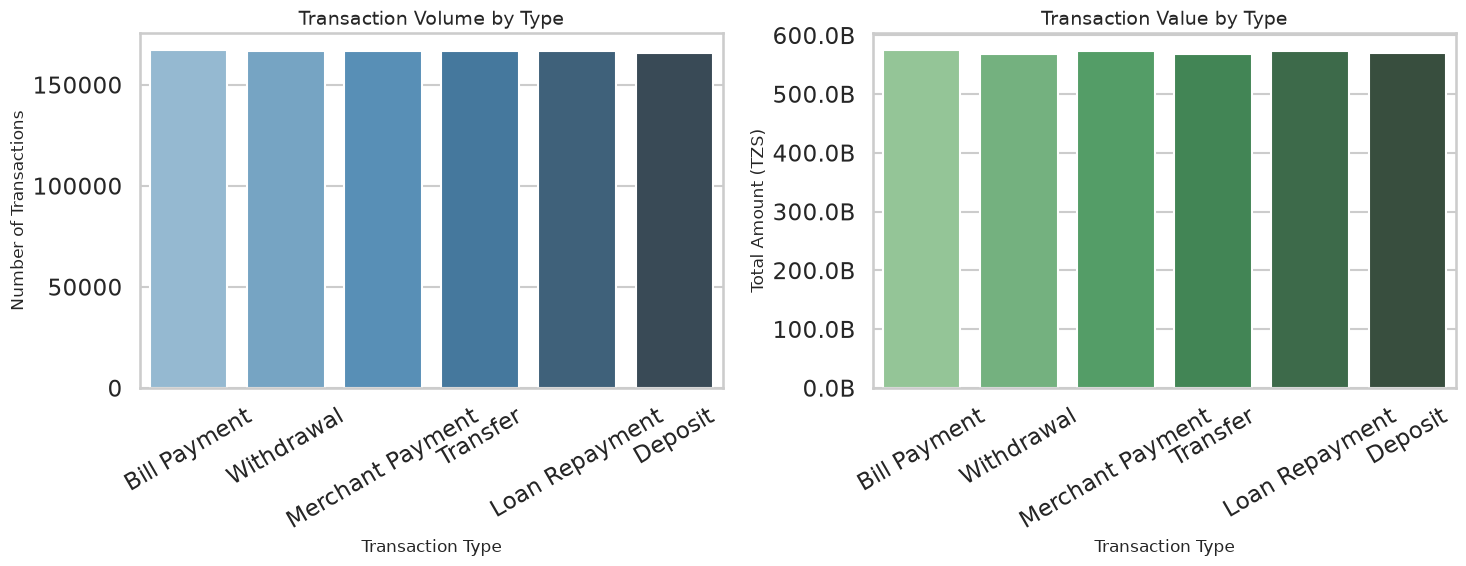

In [4]:
type_summary = transaction_type_summary(transactions)
display(type_summary.assign(
    total_amount_tzs=type_summary['total_amount'].map(format_tzs),
    average_amount_tzs=type_summary['average_amount'].map(format_tzs),
))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=type_summary, x='transaction_type', y='transaction_count', hue='transaction_type', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Transaction Volume by Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=type_summary, x='transaction_type', y='total_amount', hue='transaction_type', palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('Transaction Value by Type')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Total Amount (TZS)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## Section 4: Digital Banking Channel Analysis

Measure adoption across mobile, USSD, ATM, branch, and internet channels.

In [5]:
channels = channel_summary(transactions)
display(channels)

digital_share = transactions['channel'].isin(DIGITAL_CHANNELS).mean() * 100
top_channel = channels.iloc[0]
print(f"Insight: {top_channel['channel']} leads with {top_channel['channel_percentage']:.1f}% of transactions.")
print(f'Digital channels (Mobile App, USSD, Internet Banking) represent {digital_share:.1f}% of all transactions.')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=channels, x='channel', y='channel_transaction_count', hue='channel', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Channel Usage Distribution')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Transaction Count')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=channels, x='channel', y='channel_total_value', hue='channel', palette='mako', legend=False, ax=axes[1])
axes[1].set_title('Channel Transaction Value Comparison')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Total Value (TZS)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:.1f}T'))
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
save_figure(fig, 'channel_usage.png')
plt.show()


,channel,channel_transaction_count,channel_total_value,channel_percentage
3,Mobile App,450090,497284819400,45.01
4,USSD,299822,248375292500,29.98
0,ATM,149908,413644572400,14.99
1,Branch,70095,1938801580500,7.01
2,Internet Banking,30085,331717726100,3.01


Insight: Mobile App leads with 45.0% of transactions.
Digital channels (Mobile App, USSD, Internet Banking) represent 78.0% of all transactions.


## Section 5: Transaction Trend Analysis

Business questions:
- Are transactions growing?
- Which months have highest activity?


In [6]:
transactions['transaction_day'] = transactions['transaction_date'].dt.day_name()
monthly_trends = monthly_trend_summary(transactions)
display(monthly_trends.tail())

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.lineplot(data=monthly_trends, x='year_month', y='monthly_volume', marker='o', ax=axes[0], color='#1f4e79')
axes[0].set_title('Transactions per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Transaction Volume')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly_trends, x='year_month', y='monthly_value', marker='o', ax=axes[1], color='#2e75b6')
axes[1].set_title('Transaction Value per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Value (TZS)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:.1f}T'))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
save_figure(fig, 'transaction_trends.png')
plt.show()


,year_month,monthly_volume,monthly_value
19,2026-08,42248,141596468700
20,2026-09,41240,139336533100
21,2026-10,42470,146879068800
22,2026-11,41241,142477925400
23,2026-12,42344,144868616100


## Section 6: Time-Based Transaction Analysis

Questions:
- What are peak banking hours?
- When should digital systems expect higher traffic?


In [7]:
hourly_summary = hourly_transaction_summary(transactions)
display(hourly_summary.head())

heatmap_data = (
    transactions.groupby(['transaction_day', 'transaction_hour'])
    .size()
    .reset_index(name='transaction_count')
)
heatmap_pivot = heatmap_data.pivot(index='transaction_day', columns='transaction_hour', values='transaction_count')
heatmap_pivot = heatmap_pivot.reindex(DAY_ORDER)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', ax=ax)
ax.set_title('Transaction Volume Heatmap: Day of Week vs Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
save_figure(fig, 'transaction_heatmap.png')
plt.show()

peak_hour = hourly_summary.loc[hourly_summary['transaction_count'].idxmax(), 'transaction_hour']
print(f'Peak banking hour: {int(peak_hour):02d}:00')


,transaction_hour,transaction_count,total_amount
0,0,41863,142576601700
1,1,41394,144576182700
2,2,41964,143146931700
3,3,41856,142088434300
4,4,41620,142410486800


Peak banking hour: 02:00


## Section 7: Regional Transaction Analysis

Business questions:
- Which regions generate the highest banking activity?
- Which regions may need more banking services?


In [8]:
regional_summary = regional_transaction_summary(transactions, customers)
display(regional_summary)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=regional_summary, x='region', y='transaction_value', hue='region', palette='crest', legend=False, ax=ax)
ax.set_title('Top Regions by Transaction Value')
ax.set_xlabel('Region')
ax.set_ylabel('Transaction Value (TZS)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:.1f}T'))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
save_figure(fig, 'transaction_by_region.png')
plt.show()

fig_px = px.bar(regional_summary, x='region', y='transaction_value', hover_data=['transaction_count'], title='Regional Transaction Value')
fig_px.update_layout(xaxis_title='Region', yaxis_title='Transaction Value (TZS)')
fig_px.show()


,region,transaction_count,transaction_value,average_transaction
7,Tabora,103097,353822904800,3.431942e+06
9,Zanzibar,100554,347388251400,3.454743e+06
8,Tanga,100978,347101976500,3.437402e+06
4,Mbeya,100785,345381955800,3.426918e+06
6,Mwanza,101848,345213505500,3.389497e+06
2,Dodoma,99736,343221994900,3.441305e+06
5,Morogoro,98988,339379908400,3.428495e+06
3,Kilimanjaro,98217,337289022700,3.434121e+06
1,Dar es Salaam,98467,335969319500,3.411999e+06
0,Arusha,97330,335055151400,3.442465e+06


## Section 8: Customer Transaction Behavior

Classify customers by transaction frequency for engagement targeting.

,customer_id,number_of_transactions,total_transaction_amount,average_transaction_amount,activity_segment
0,CUST000001,2,2821000,1.410500e+06,Low Activity Customers
1,CUST000002,9,10091700,1.121300e+06,Medium Activity Customers
2,CUST000003,20,55741300,2.787065e+06,High Activity Customers
3,CUST000005,12,59028300,4.919025e+06,Medium Activity Customers
4,CUST000006,9,12632200,1.403578e+06,Medium Activity Customers


activity_segment
Medium Activity Customers    34533
Low Activity Customers       24590
High Activity Customers      14997
Name: count, dtype: int64

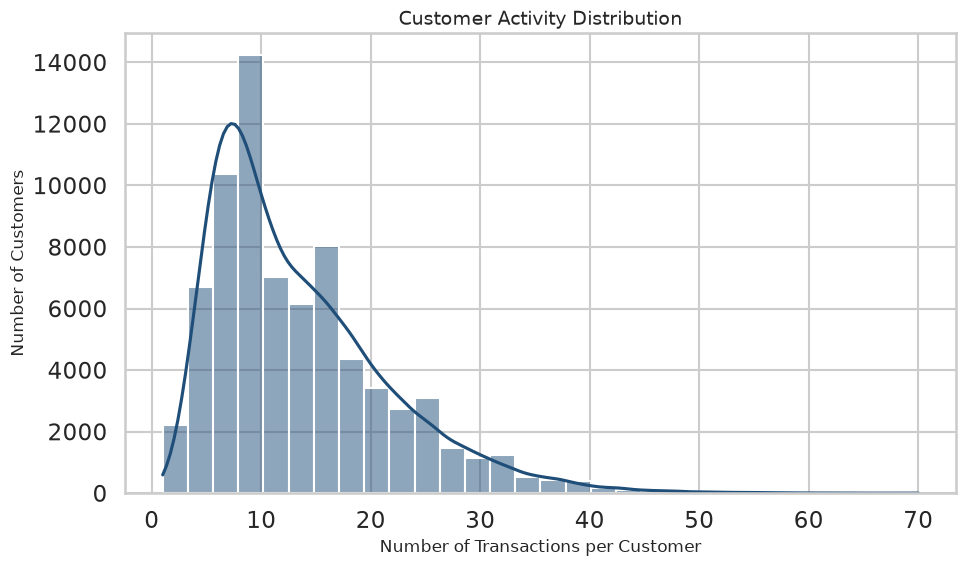

In [9]:
customer_profile = customer_transaction_profile(transactions)
customer_profile = classify_customer_activity(customer_profile)
display(customer_profile.head())
display(customer_profile['activity_segment'].value_counts())

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(customer_profile['number_of_transactions'], bins=30, kde=True, color='#1f4e79', ax=ax)
ax.set_title('Customer Activity Distribution')
ax.set_xlabel('Number of Transactions per Customer')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()


## Section 9: Transaction Analytics Insights

Data-driven findings for banking management and digital strategy teams.


In [10]:
insights = []
total_value = transactions['amount'].sum()
top_type = type_summary.iloc[0]
top_value_type = type_summary.sort_values('total_amount', ascending=False).iloc[0]
top_channel = channels.iloc[0]
top_region = regional_summary.iloc[0]
bottom_region = regional_summary.iloc[-1]
peak_month = monthly_trends.loc[monthly_trends['monthly_volume'].idxmax()]
digital_pct = transactions['channel'].isin(DIGITAL_CHANNELS).mean() * 100
branch_pct = (transactions['channel'] == 'Branch').mean() * 100
deposit_withdraw = type_summary.set_index('transaction_type')[['transaction_count']]
high_activity_pct = (customer_profile['activity_segment'] == 'High Activity Customers').mean() * 100

insights.extend([
    f"1. {top_channel['channel']} contributes the highest transaction volume at {top_channel['channel_percentage']:.1f}%.",
    f"2. Total transaction value through the bank is {format_tzs(total_value)}.",
    f"3. Peak transaction periods occur around hour {int(peak_hour):02d}:00, indicating business-hour banking behavior.",
    f"4. {top_region['region']} generates the highest transaction value ({format_tzs(top_region['transaction_value'])}).",
    f"5. Digital channels represent {digital_pct:.1f}% of transactions, showing strong mobile-first adoption.",
    f"6. Branch transactions account for only {branch_pct:.1f}% of volume, reducing branch dependence.",
    f"7. '{top_type['transaction_type']}' is the most frequent transaction type with {int(top_type['transaction_count']):,} transactions.",
    f"8. '{top_value_type['transaction_type']}' creates the highest monetary value ({format_tzs(top_value_type['total_amount'])}).",
    f"9. {peak_month['year_month']} recorded the highest monthly transaction volume ({int(peak_month['monthly_volume']):,}).",
    f"10. High Activity Customers represent {high_activity_pct:.1f}% of transacting customers and should be prioritized for retention.",
    f"11. {bottom_region['region']} has the lowest transaction value and may benefit from expanded banking services.",
    f"12. Average transaction size is {format_tzs(transactions['amount'].mean())}, useful for liquidity and channel capacity planning.",
])
for insight in insights:
    print(insight)


1. Mobile App contributes the highest transaction volume at 45.0%.
2. Total transaction value through the bank is TZS 3429.82 Billion.
3. Peak transaction periods occur around hour 02:00, indicating business-hour banking behavior.
4. Tabora generates the highest transaction value (TZS 353.82 Billion).
5. Digital channels represent 78.0% of transactions, showing strong mobile-first adoption.
6. Branch transactions account for only 7.0% of volume, reducing branch dependence.
7. 'Bill Payment' is the most frequent transaction type with 167,263 transactions.
8. 'Bill Payment' creates the highest monetary value (TZS 575.05 Billion).
9. 2025-07 recorded the highest monthly transaction volume (42,796).
10. High Activity Customers represent 20.2% of transacting customers and should be prioritized for retention.
11. Arusha has the lowest transaction value and may benefit from expanded banking services.
12. Average transaction size is TZS 3.43 Million, useful for liquidity and channel capacity p

## Section 10: Export Results

Save summary tables and charts for reporting and dashboard development.

In [11]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)
transaction_summary.to_csv(REPORT_DIR / 'transaction_summary.csv', index=False)
channels.to_csv(REPORT_DIR / 'channel_summary.csv', index=False)
type_summary.to_csv(REPORT_DIR / 'transaction_type_summary.csv', index=False)
regional_summary.to_csv(REPORT_DIR / 'regional_transaction_analysis.csv', index=False)
customer_profile.to_csv(REPORT_DIR / 'customer_transaction_profile.csv', index=False)

print('Exported reports:')
for file in [
    'transaction_summary.csv',
    'channel_summary.csv',
    'transaction_type_summary.csv',
    'regional_transaction_analysis.csv',
    'customer_transaction_profile.csv',
]: 
    print(f' - {REPORT_DIR / file}')
print('\nExported charts:')
for chart in sorted(CHART_DIR.glob('*.png')):
    print(f' - {chart}')


Exported reports:
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/transaction_summary.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/channel_summary.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/transaction_type_summary.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/regional_transaction_analysis.csv
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/customer_transaction_profile.csv

Exported charts:
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/charts/channel_usage.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/charts/transaction_by_region.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/charts/transaction_heatmap.png
 - /mnt/d/msilu/data/Banking-Analytics-Platform/reports/transaction_analysis/charts/transaction_trends.png
